Shape of training data: (398, 30)
Shape of testing data: (171, 30)

Accuracy of Logistic Regression: 0.9766
Classification Report for KNN:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Mean Squared Error (MSE): 0.56
R-squared (R2) Score: 0.5758


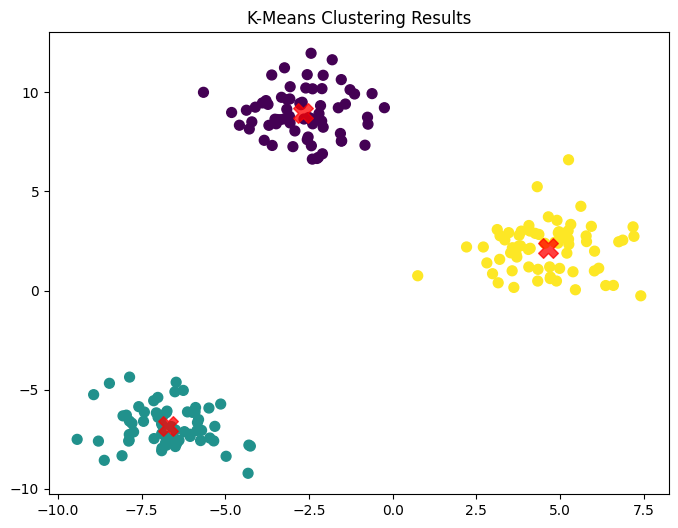

Accuracy of Random Forest: 1.0000


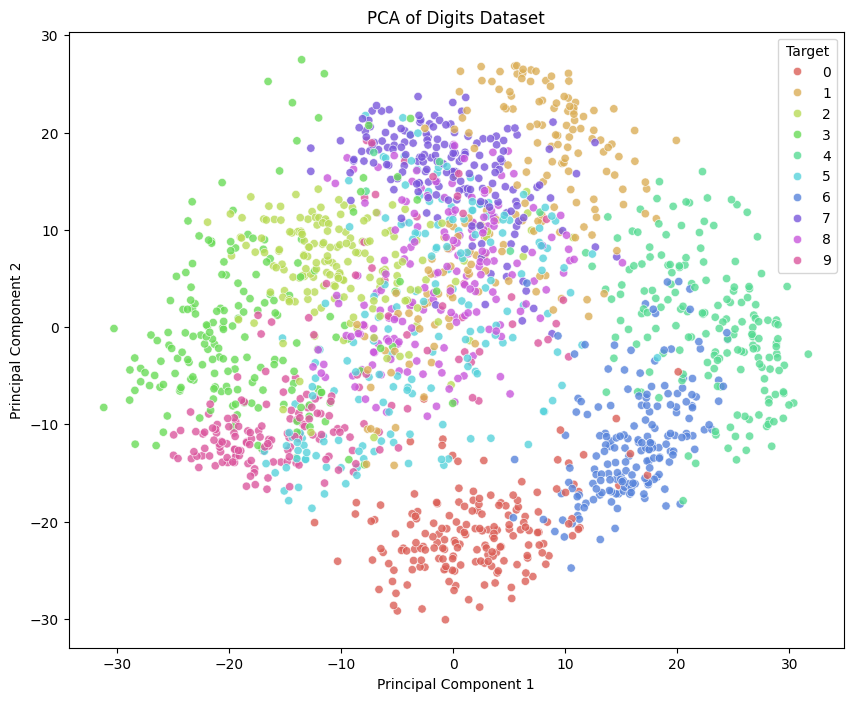

Accuracy of Text Classification Pipeline: 0.9865
R-squared (R2) Score of Lasso: 0.3576

Lasso Coefficients:
age: 0.0000
sex: -0.0000
bmi: 413.4318
bp: 34.8305
s1: 0.0000
s2: 0.0000
s3: -0.0000
s4: 0.0000
s5: 258.1529
s6: 0.0000

Number of features used: 3


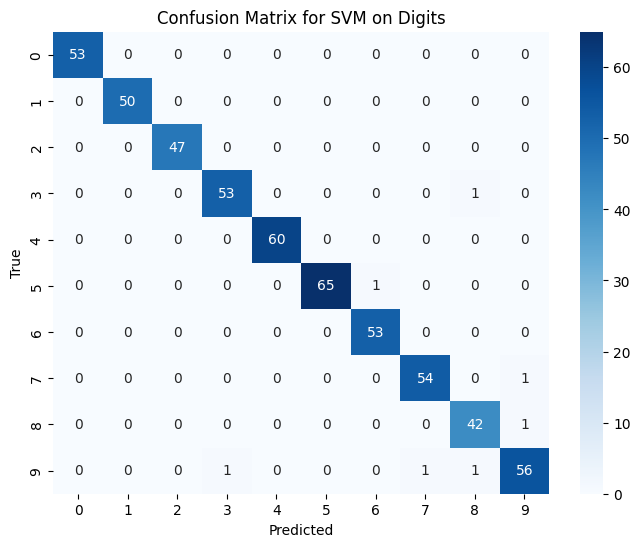

R-squared (R2) Score of Gradient Boosting: 0.7756
R-squared (R2) Score of Linear Regression (from Q3): 0.3576

Improvement over Linear Regression: 0.4181


In [1]:
# @title 📝 แบบฝึกหัด Machine Learning 10 ข้อ (ฉบับ .ipynb)
# @markdown ---
# @markdown สวัสดีครับนักเรียน! นี่คือชุดโจทย์สำหรับฝึกฝนการสร้างโมเดล Machine Learning ทั้ง 10 ข้อในรูปแบบไฟล์ Notebook
# @markdown
# @markdown **คำแนะนำ:** ให้กดปุ่ม Play (▶️) ที่ด้านซ้ายของแต่ละเซลล์เพื่อรันโค้ดไปทีละขั้น ลองทำความเข้าใจและแก้ไขโค้ดเพื่อทดลองด้วยตัวเองนะครับ

# @markdown ---

# @markdown ## ข้อที่ 1: การจำแนกประเภทเนื้องอก (Binary Classification)
# @markdown **โจทย์:** สร้างโมเดล `Logistic Regression` เพื่อจำแนกเนื้องอกว่าเป็น **เนื้อร้าย (Malignant)** หรือ **ไม่ร้าย (Benign)**
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. โหลดและเตรียมข้อมูล
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of training data:", X_train.shape)
print("Shape of testing data:", X_test.shape)

# 2. สร้างและฝึกฝนโมเดล
# YOUR CODE HERE
model_lr = LogisticRegression(max_iter=5000) # เพิ่ม max_iter เพื่อให้แน่ใจว่า converge
model_lr.fit(X_train, y_train)

# 3. ทำนายและประเมินผล
predictions = model_lr.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nAccuracy of Logistic Regression: {accuracy:.4f}")

# @markdown ---

# @markdown ## ข้อที่ 2: การจำแนกสายพันธุ์ดอกไม้ (Multi-class Classification)
# @markdown **โจทย์:** สร้างโมเดล `K-Nearest Neighbors (KNN)` เพื่อจำแนกสายพันธุ์ดอกไอริส (Iris) ออกเป็น 3 สายพันธุ์
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# 1. โหลดและเตรียมข้อมูล
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. สร้างและฝึกฝนโมเดล
# YOUR CODE HERE
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)


# 3. ทำนายและประเมินผล
predictions = model_knn.predict(X_test)
report = classification_report(y_test, predictions, target_names=iris.target_names)

print("Classification Report for KNN:\n")
print(report)

# @markdown ---

# @markdown ## ข้อที่ 3: การทำนายราคาบ้าน (Regression)
# @markdown **โจทย์:** สร้างโมเดล `Linear Regression` เพื่อทำนายราคาบ้านในรัฐแคลิฟอร์เนีย และประเมินผลด้วย MSE และ R-squared
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. โหลดและเตรียมข้อมูล
housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. สร้างและฝึกฝนโมเดล
# YOUR CODE HERE
model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train, y_train)

# 3. ทำนายและประเมินผล
predictions = model_lin_reg.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# @markdown ---

# @markdown ## ข้อที่ 4: การจัดกลุ่มลูกค้า (Clustering)
# @markdown **โจทย์:** ใช้ `K-Means` แบ่งข้อมูลลูกค้าที่ไม่มีกลุ่ม ออกเป็น 3 กลุ่ม และแสดงผลด้วยภาพ
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. สร้างข้อมูลจำลอง
X, y_true = make_blobs(n_samples=200, centers=3, cluster_std=1.2, random_state=42)

# 2. สร้างและฝึกฝนโมเดล K-Means
# YOUR CODE HERE
model_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = model_kmeans.fit_predict(X)

# 3. แสดงผลลัพธ์
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = model_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title("K-Means Clustering Results")
plt.show()

# @markdown ---

# @markdown ## ข้อที่ 5: การจำแนกประเภทไวน์ (Ensemble Method)
# @markdown **โจทย์:** สร้างโมเดล `Random Forest Classifier` เพื่อจำแนกประเภทของไวน์
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier

# 1. โหลดและเตรียมข้อมูล
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. สร้างและฝึกฝนโมเดล
# YOUR CODE HERE
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# 3. ทำนายและประเมินผล
accuracy = model_rf.score(X_test, y_test)
print(f"Accuracy of Random Forest: {accuracy:.4f}")

# @markdown ---

# @markdown ## ข้อที่ 6: การลดมิติข้อมูลรูปภาพ (Dimensionality Reduction)
# @markdown **โจทย์:** ใช้ `PCA` ลดมิติข้อมูลรูปภาพตัวเลขจาก 64 มิติ เหลือ 2 มิติ และพล็อตเพื่อดูการกระจายตัว
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

# 1. โหลดข้อมูล
digits = load_digits()
X, y = digits.data, digits.target

# 2. ทำ PCA เพื่อลดมิติ
# YOUR CODE HERE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. แสดงผล
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Target'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="Principal Component 1", y="Principal Component 2",
    hue="Target",
    palette=sns.color_palette("hls", 10),
    data=pca_df,
    legend="full",
    alpha=0.8
)
plt.title("PCA of Digits Dataset")
plt.show()


# @markdown ---

# @markdown ## ข้อที่ 7: การคัดกรองข่าวสาร (Text Classification)
# @markdown **โจทย์:** สร้าง `Pipeline` ที่ประกอบด้วย `TfidfVectorizer` และ `MultinomialNB` เพื่อจำแนกหัวข้อข่าว
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# 1. โหลดและเตรียมข้อมูล
categories = ['comp.graphics', 'rec.sport.baseball']
data = fetch_20newsgroups(subset='all', categories=categories, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

# 2. สร้างและฝึกฝน Pipeline
# YOUR CODE HERE
text_clf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB()),
])
text_clf_pipeline.fit(X_train, y_train)

# 3. ประเมินผล
accuracy = text_clf_pipeline.score(X_test, y_test)
print(f"Accuracy of Text Classification Pipeline: {accuracy:.4f}")

# @markdown ---

# @markdown ## ข้อที่ 8: การทำนายโรคเบาหวานพร้อมคัดเลือกฟีเจอร์ (Regression with Regularization)
# @markdown **โจทย์:** ใช้ `Lasso Regression` ทำนายความก้าวหน้าของโรคเบาหวาน และดูว่าฟีเจอร์ใดถูกตัดออกไป
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
import numpy as np

# 1. โหลดและเตรียมข้อมูล
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. สร้างและฝึกฝนโมเดล
# YOUR CODE HERE
model_lasso = Lasso(alpha=1.0)
model_lasso.fit(X_train, y_train)

# 3. ประเมินผลและดูค่าสัมประสิทธิ์
r2 = model_lasso.score(X_test, y_test)
print(f"R-squared (R2) Score of Lasso: {r2:.4f}\n")

print("Lasso Coefficients:")
for feature, coef in zip(diabetes.feature_names, model_lasso.coef_):
    print(f"{feature}: {coef:.4f}")

print(f"\nNumber of features used: {np.sum(model_lasso.coef_ != 0)}")

# @markdown ---

# @markdown ## ข้อที่ 9: การจำแนกรูปภาพตัวเลข (Image Classification)
# @markdown **โจทย์:** สร้างโมเดล `Support Vector Machine (SVM)` เพื่อจำแนกรูปภาพลายมือตัวเลข และแสดงผลด้วย `Confusion Matrix`
from sklearn.datasets import load_digits
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# 1. โหลดและเตรียมข้อมูล
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. สร้างและฝึกฝนโมเดล
# YOUR CODE HERE
model_svm = SVC(kernel='rbf', random_state=42)
model_svm.fit(X_train, y_train)

# 3. ประเมินผลด้วย Confusion Matrix
predictions = model_svm.predict(X_test)
cm = confusion_matrix(y_test, predictions)

# แสดงผล Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for SVM on Digits')
plt.show()

# @markdown ---

# @markdown ## ข้อที่ 10: การทำนายด้วยโมเดลที่ทรงพลังขึ้น (Advanced Regression)
# @markdown **โจทย์:** ใช้ `Gradient Boosting Regressor` เพื่อทำนายราคาบ้าน และเปรียบเทียบประสิทธิภาพกับ `Linear Regression`
from sklearn.ensemble import GradientBoostingRegressor

# 1. โหลดและเตรียมข้อมูล (ใช้ข้อมูลจากข้อ 3)
housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. สร้างและฝึกฝนโมเดล
# YOUR CODE HERE
model_gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gbr.fit(X_train, y_train)

# 3. ประเมินผล
r2_gbr = model_gbr.score(X_test, y_test)
print(f"R-squared (R2) Score of Gradient Boosting: {r2_gbr:.4f}")
print(f"R-squared (R2) Score of Linear Regression (from Q3): {r2:.4f}") # r2 from Q3
print(f"\nImprovement over Linear Regression: {r2_gbr - r2:.4f}")